## Importing libraries

In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## Creating database and table

In [36]:
# Create database and table
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

## Drop table if already exists


In [39]:
cursor.execute("DROP TABLE IF EXISTS sales")

## Creating sales table

In [40]:
cursor.execute("""
CREATE TABLE sales (
    Id INTEGER PRIMARY KEY,
    Product TEXT,
    Quantity INTEGER,
    Price REAL
)
""")

## Inserting sample data

In [41]:
sample_data = [
    ('Apple', 30, 0.5),
    ('Banana', 50, 0.3),
    ('Orange', 40, 0.4),
    ('Apple', 20, 0.5),
    ('Banana', 30, 0.3),
    ('Orange', 10, 0.4),
    ('Grapes', 25, 0.6)
]

In [42]:
cursor.executemany("INSERT INTO sales (Product, Quantity, Price) VALUES (?, ?, ?)", sample_data)
conn.commit()


## Run SQL Query to get summary

In [43]:
query = """
SELECT
    Product,
    SUM(Quantity) AS Total_Qty,
    ROUND(SUM(Quantity * Price), 2) AS Revenue
FROM sales
GROUP BY product
"""

In [44]:
df = pd.read_sql_query(query, conn)

In [45]:
# Print output

print("Sales Summary:")
print(df)


Sales Summary:
  Product  Total_Qty  Revenue
0   Apple         50     25.0
1  Banana         80     24.0
2  Grapes         25     15.0
3  Orange         50     20.0


##  Plotting  bar chart

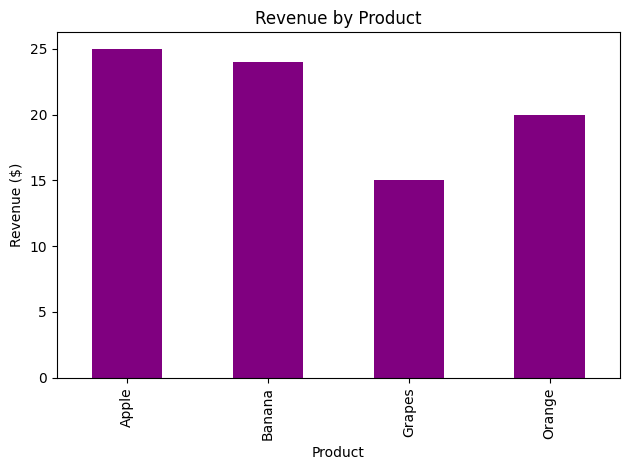

In [46]:
# Create the plot and capture the Axes object
ax = df.plot(kind='bar', x='Product', y='Revenue', color='purple', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()

## Closing the connection

In [49]:
conn.close()